# **SERIES TEMPORALES**
##**Fecha: 13/04/2026**




## **¿Qué significa TIME SERIES DATA?**

* Serie de puntos/observaciones ordenados en el tiempo.

* Las observaciones que se recopilan normalmente se pueden recopilar:
    * Cada segundo, minuto u hora.
    * Diariamente.
    * Mensualmente.
    * Trimestralmente o anualmente.

* **SUPUESTO PRINCIPAL:** Asumen que el patrón y el comportamiento pasado continuarán en el futuro.

## **EJEMPLOS**

* Datos de Ventas Mensuales.
* Ingresos trimestrales o anuales de cualquier empresa que cotice en bolsa.
* Datos de sensores industruales o dispositivos inteligentes.
* Previsión energética.

## **CONCEPTOS CLAVE**

* Tendencia
* Estacionalidad
* Cíclico
* Estacionariedad






### **1. Tendencia**

* Existe una tendencia cuando hay un **aumento** o **disminución** a largo plazo de los datos.

* Veamos la serie de viajes internacionales, el patrón de viaje ha aumentando continuamente con los años.

* Podemos encontrar una tendencia **creciente** o una tendencia **decreciente** y no tiene que ser lineal, puede ser logística o incluso pueden haber cambios de direción.
    * **Crecimiento Lineal:**
        * Aumenta o disminuye de manera constante.
        * Ejemplo: número de usuarios de una app crece cada mes.
    * **Crecimiento Logístico:**
        * Crece rápidamente al inicio, luego se estabiliza porque hay un límite.
        * Ejemplo: población de una ciudad tiene un número máximo de habitantes.

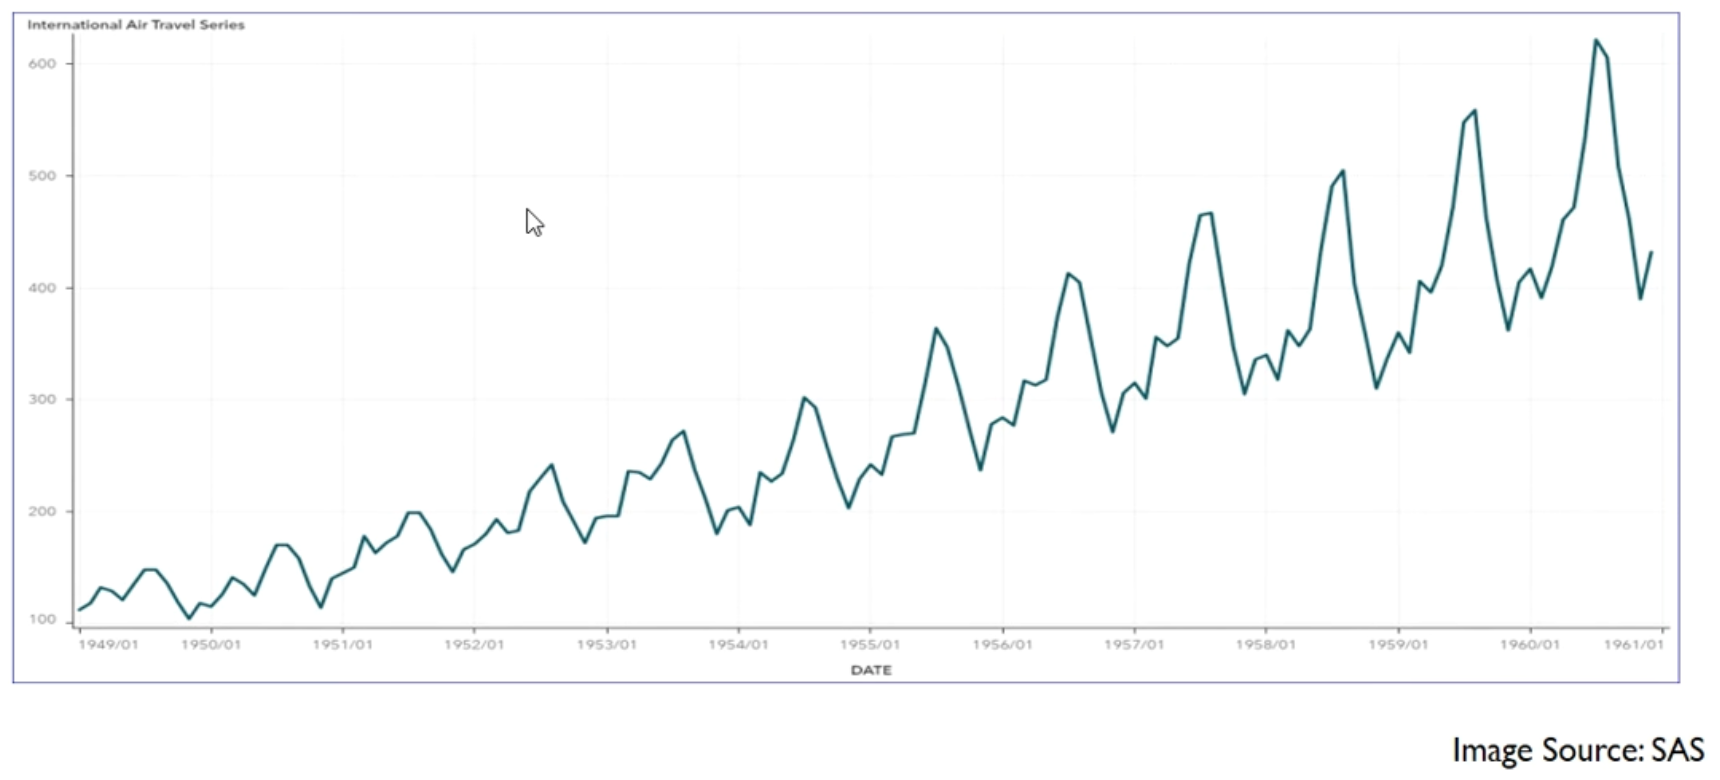


### **2. Estacionalidad**

* Se produce cuando una serie temporal se ve afectada por un patrón que suele ocurrir de forma regular. ***Pasa siempre en las mismas fechas.***

* Son cambios que se repiten en periodos cortos (días, meses, años).

* Ejemplo: temporadas navideñas, fin de mes, verano semana santa, black friday, otros.

* Tipo de Estacionalidad:
    *  Aditiva:
        * El cambio es más o menos constante, por ejemplo, siempre suben +100 ventas en Navidad.
    *  Multiplicativa:
        * El cambio depende del nivel de la serie, por ejemplo, las ventas aumentan un 20% en Navidad.

* <> **CICLO** también es repetitivo, pero no ocurre en fechas exactas ni tan predecibles (por ejemplo, crisis económica).

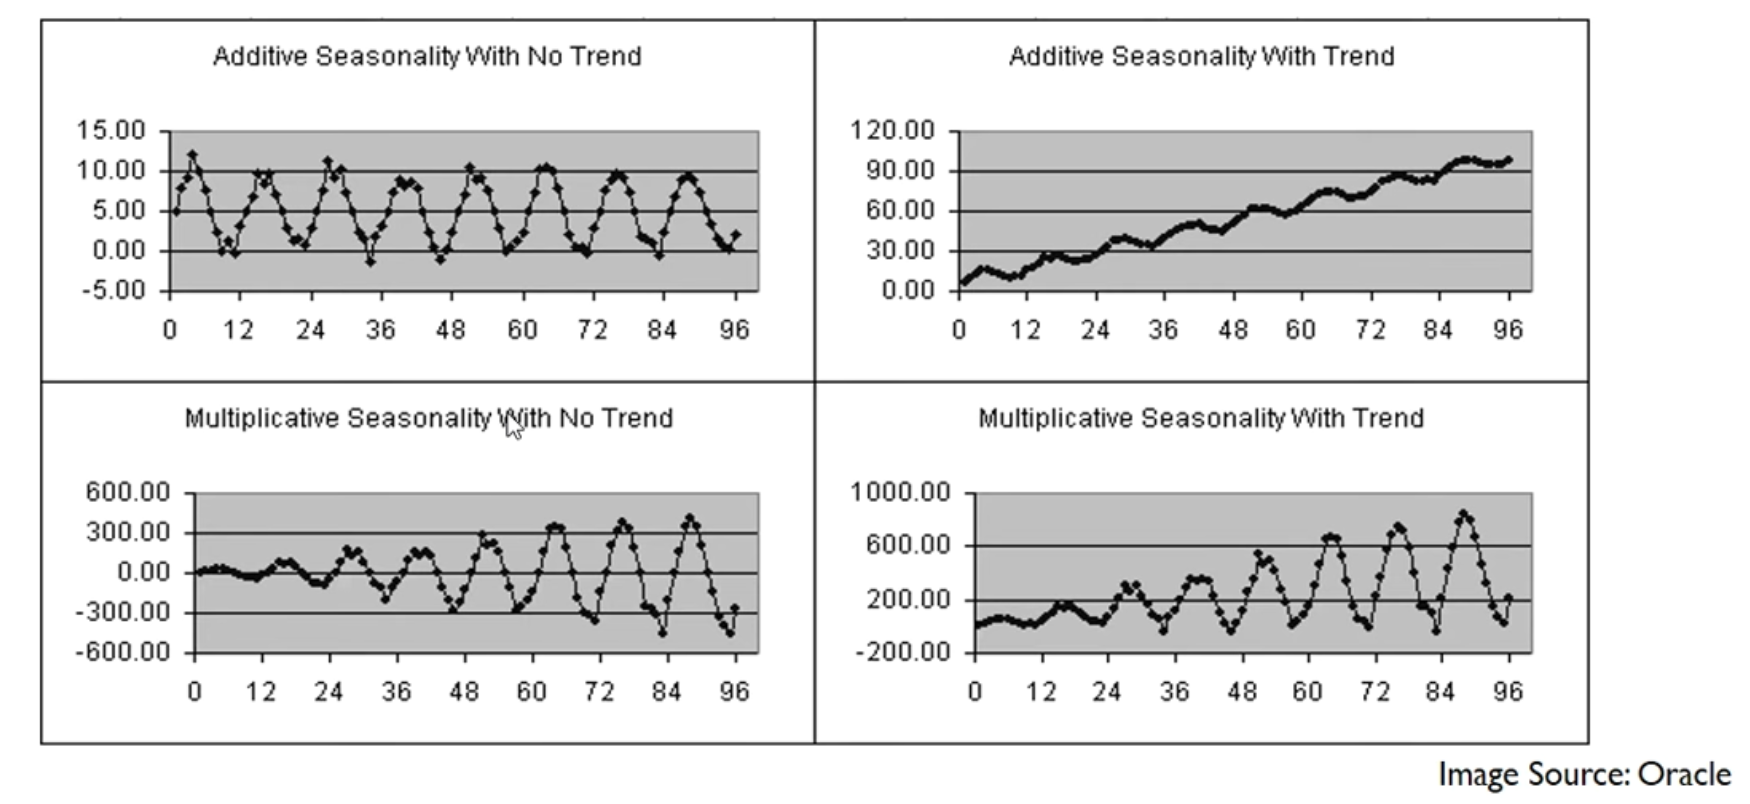


### **3. Estacionariedad**

* Media y varianza se mantienen constantes en el tiempo.

* No estacionalidad ni tendencia (se mueve alrededor de su media).

* En presencia de heterosedasticidad (variabilidad que aumenta con el nivel de la serie).

* En presencia de autocovarianza (mide como una serie se relaciona con ella misma en dos momentos diferentes, indicando si los valores altos o bajos tienen a repetirse tras cierto tiempo).


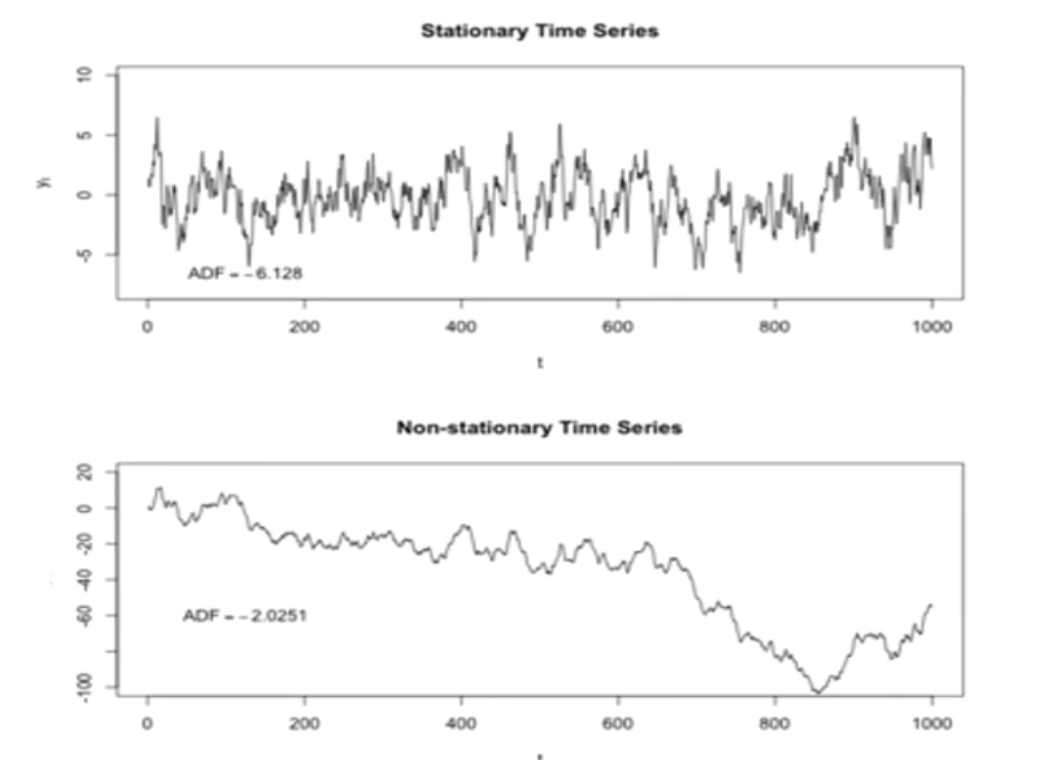

### **COSAS PARA RECORDAR**

* Las series temporales pueden estar espaciadas de forma irregular.

* Factores externos pueden contrubir a la variable objetivo y deben tenerse en cuenta.

* Las series temporales consisten principalmente en **análisis de datos.**

* Tener mucho cuidado con información faltante.

## **Series Temporales Python**

### **Importar Series Temporales**

Para importar **series temporales** en Python debemos tener en cuenta que:

* Los datos de una serie suelen almacenarse en **.csv** u otros formatos de hoja de cáculo.

* Contienen dos columnas: la fecha y el valor medido.

Veamos un ejemplo de lectura...

In [471]:
from dateutil.parser import parse
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

Vamos a leer un archivo CSV sobre ventas de medicamentos en Australia como un dataframe de pandas con **read_csv()** y le vamos a añadir el argumento **parse_date=['date']** para que la columna de fecha la analice como un campo de fecha.

In [472]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/a10.csv', parse_dates=['date'])
df.head()

,date,value
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869


Alternativamente podríamos importarlo como una serie de pandas con la fecha como índice, especificando el argumento **index_col** en el **pd.read_csv()**

In [473]:
ser = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/a10.csv', parse_dates=['date'],index_col='date')
ser.head()

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


Establecer la fecha como un índice nos permite hacer consultas rápidas, hacer subconjuntos y filtros de datos...

In [474]:
ser.loc['1991-08-01':'1996-08-01']

,value
date,
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869
1991-12-01,4.306371
...,...
1996-04-01,5.597126
1996-05-01,6.110296
1996-06-01,5.689161


In [475]:
ser.loc['1991':'1994']

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869
1991-12-01,4.306371
1992-01-01,5.088335
1992-02-01,2.814520
1992-03-01,2.985811


Puedo graficar de manera rápida los datos...

<Axes: xlabel='date'>

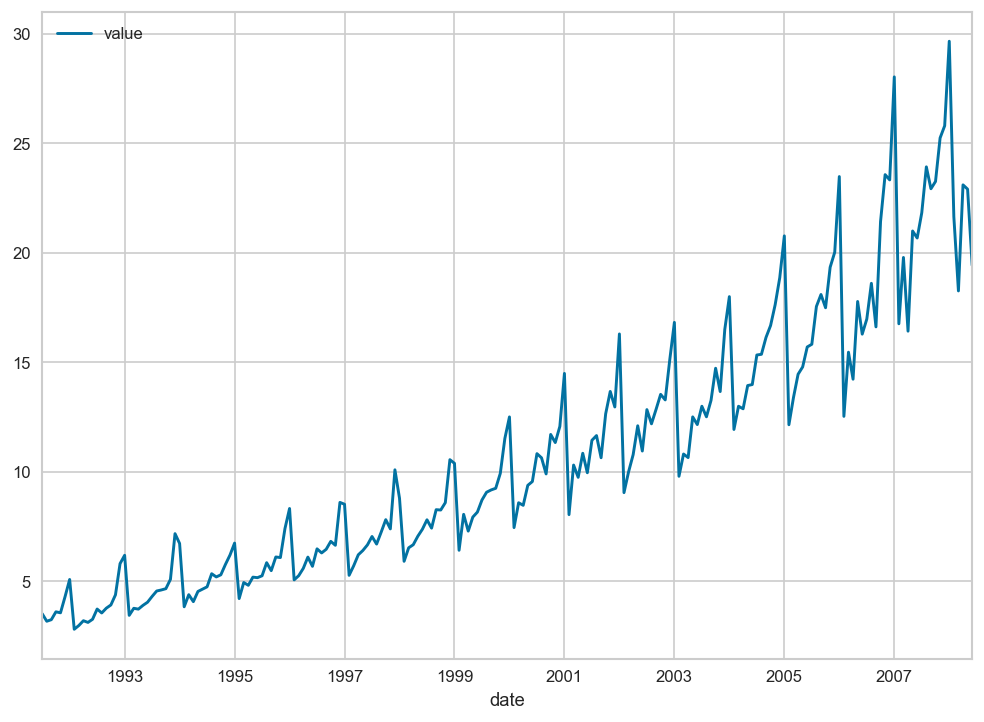

In [476]:
ser.plot(grid=True)

También podemos encontrar **datos panel** que también son conjuntos de datos basados en el tiempo.

La diferencia radica en que contiene una o más variables relacionadas que se miden en los mismos periodos de tiempo.

In [477]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/MarketArrivals.csv')
df = df.loc[df.market=='MUMBAI', :]
df.head()

,market,month,year,quantity,priceMin,priceMax,priceMod,state,city,date
6654,MUMBAI,January,2004,267100,719,971,849,MS,MUMBAI,January-2004
6655,MUMBAI,January,2005,275845,261,513,387,MS,MUMBAI,January-2005
6656,MUMBAI,January,2006,228000,315,488,402,MS,MUMBAI,January-2006
6657,MUMBAI,January,2007,205200,866,1136,997,MS,MUMBAI,January-2007
6658,MUMBAI,January,2008,267550,348,550,448,MS,MUMBAI,January-2008


### **Ejemplo Series Temporales**

Vamos a utilizar un famoso conjunto de datos sobre la evolución del número de pasajeros en una famosa aerolina americana desde 1949 a 1960.

In [478]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime

Vamos a leer el conjunto de datos...

In [479]:
total_data = sns.load_dataset('flights')
total_data.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [480]:
total_data.shape

(144, 3)

In [481]:
total_data.describe()

,year,passengers
count,144.000000,144.000000
mean,1954.500000,280.298611
std,3.464102,119.966317
min,1949.000000,104.000000
25%,1951.750000,180.000000
50%,1954.500000,265.500000
75%,1957.250000,360.500000
max,1960.000000,622.000000


Vamos a realizar una transformación a nuestro conjunto de datos para generar una **SERIE TEMPORAL** con dos dimensiones:

 * Temporal, que está comuesta por: month y year.
 * Dato que queremos analizar y predecir, que es el número de pasajeros.

 Para ello vamos a utilizar la función **pd.to_datetime()** para convertir varias cadenas similares a fechas en objetos datetime en pandas (objetos de fecha y hora).

In [482]:
total_data.dtypes

year             int64
month         category
passengers       int64
dtype: object

In [483]:
total_data['month'] = pd.to_datetime(total_data['month'],format='%b').dt.month
total_data['date']=pd.to_datetime(total_data[['year','month']].assign(day=1))
total_data = total_data.set_index('date')
ts = total_data['passengers']
ts.head()

date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: passengers, dtype: int64

* Hemos unificado las dos variables month y date en una única variable para poder trabajar con la serie de pasajeros. Estamos tratando de mantener un único eje para X y uno para Y.

* Es importante tener en cuenta que no hacemos un EDA en estos casos porque solo tenemos la variable temporal y la variable que queremos analizar.

* Graficamos nuestra serie temporal...o trazamos la serie...

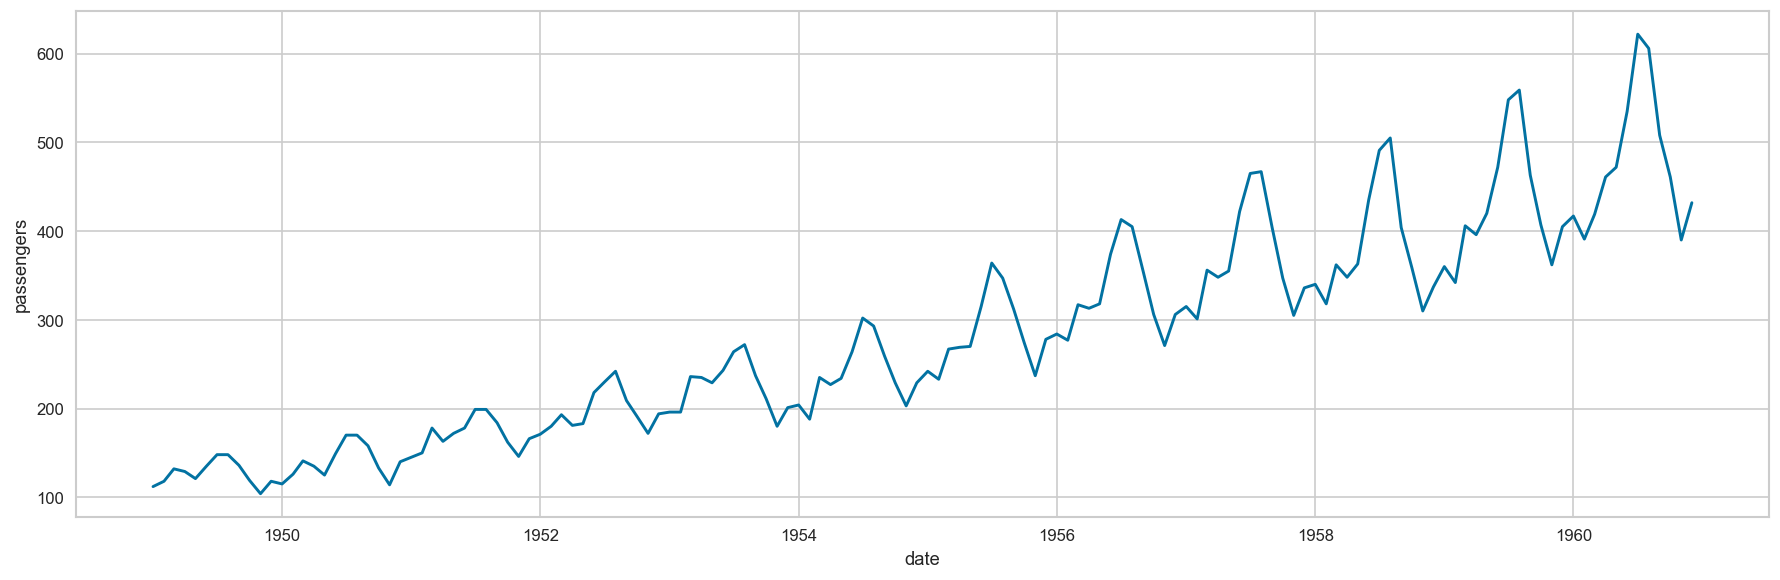

In [484]:
fig, axis = plt.subplots(figsize=(15,5))
sns.lineplot(data=ts)
plt.tight_layout()
plt.show()

* Vemos que la serie temporal representa el número de pasageros en el tiempo. El eje X concentra el plano temporal y el eje Y conserva el número de pasajeros que viaja.

* Para analizar una **SERIE TEMPORAL** debemos tener en cuenta los siguientes parámetros:
    * **Tendencia:**
        * Vemos que la tendencia es **ASCENDENTE** lo que significa que el número de pasajeros ha aumenado en el tiempo. Y esto puede deberse a varios factores: crecimiento de la insdustria aeronautica y dotación de más recursos para movilizar pasajeros, reducción de precios, mayor interés por viajes aereos, etc...
    * **Estacionalidad:**
        * Se observa cierta estacionalidad en los datos, con ciertos meses que consistentemente tienen más vuelos que otros.
        * Esto podría deberse a cierta demanda estacional (más personas volando en vacaciones).  
    * **Variabilidad:**
        * Se observan ciertos puntos de vaiabilidad, sobre todo en periodos de aumento-disminución de la demanda.
    * **Puntos atípicos (Outliers):**
        * No se aprecian outliers en la serie temporal.
    * **Puntos de inflexión:**
        * Dependiendo del año, el aumento de nñumero de pasajeros no es regular y a veces se producen variaciones en la pendiente, esos son ls puntos de inflexión.

* Por medio de un **análisis visual** podríamos ser capaces de estimar métricas a ojo, pero siempre es mejor orientar el análisis de datos matemáticos. Por ello vamos a apoyarnos en la librería **statsmodels.**


### **Descomposición de la Serie**

* Vamos a transformar la serie de pandas en un conjunto de sus componentes.

* En sí, la descomposición de una sere temporal es un proceso estadístico que separa una serie temporal en varios elementos diferenciados.

* Cada componente de la serie representa una parte de la estructura subyacente de la serie.

* Útil para entender mejor los datos y tomar decisiones informadas para construir modelos de pronóstico.

* La función **seasonal_decompose** nos dará información: tendencia, estacionalidad y residuos.

In [485]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(ts,period=12)
decomposition

**decomposition** es el objeto en donde guardamos el resultado de la descomposición y que luego voy a analizar por partes...

#### **Tendencia**

* Nos muestra el comportamento a largo plazo de la serie temporal.

* Destaca la dirección general (ascendente, descendente o estable) a lo largo del tiempo.

* Para acceder a su información recurrimos al componente de **trend** del resultado **decomposition.**

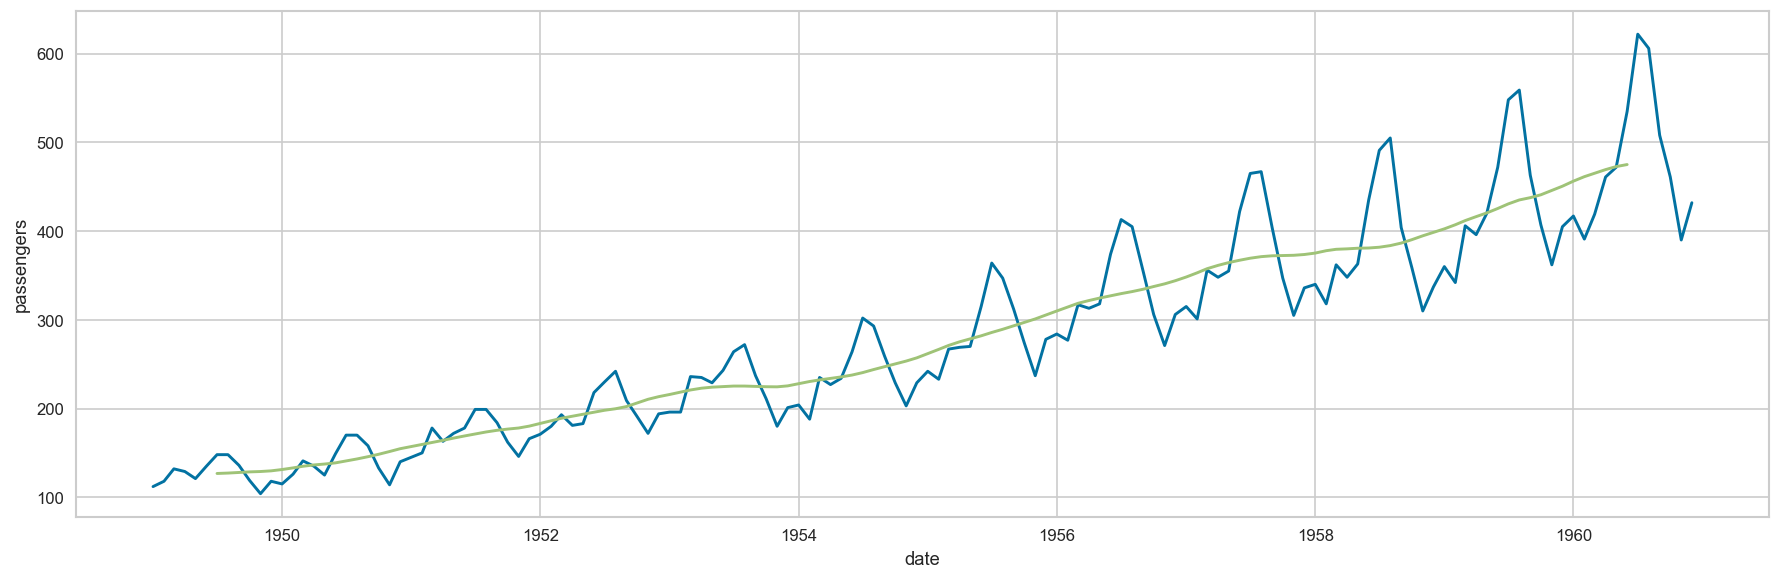

In [486]:
#Extraigo la tendencia de mi objeto descomposition
trend = decomposition.trend
fig, axis = plt.subplots(figsize=(15,5))
sns.lineplot(data=ts)
sns.lineplot(data=trend)
plt.tight_layout()
plt.show()

Confirmamos lo que observamos al inicio, existe una clara tendencia positiva a lo largo de los años.

#### **Estacionalidad/Estacionariedad**

* Nos muestra los patrones regulares que se repiten a lo largo del tiempo.

* Estos patrones se repiten en momentos regulares, como cada día, mes o año.

* Para acceder a su información recurimos al componente **seasonal** del resultado **decomposition.**



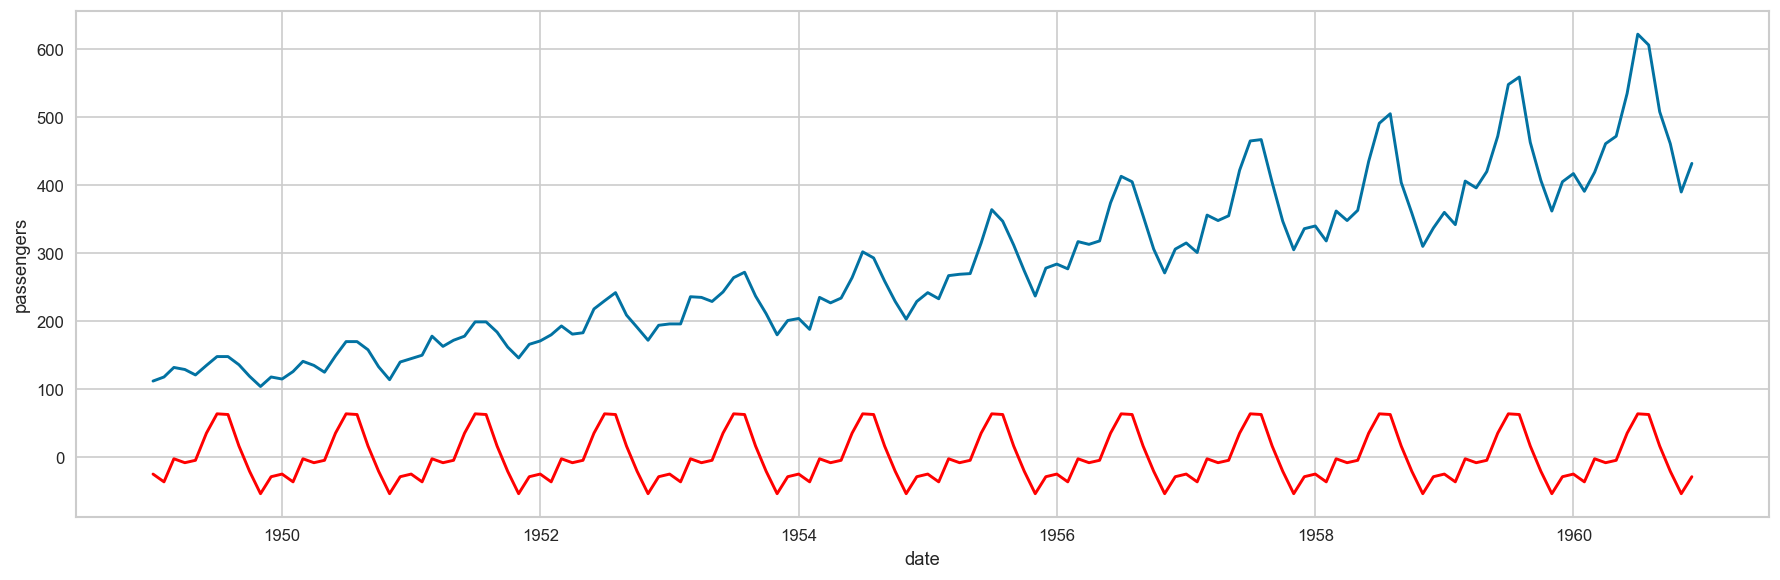

In [487]:
#Extraigo la estacionalidad de mi objeto descomposition
seasonal = decomposition.seasonal
fig, axis = plt.subplots(figsize=(15,5))
sns.lineplot(data=ts)
sns.lineplot(data=seasonal,color='red')
plt.tight_layout()
plt.show()

Para evaluar la estacionalidad de la serie temporal podemos aplicar la llamada **Prueba de Dickey-Fuller** *(Dickuey-Fuller test)*, que es un constraste de hipótesis en el que la HO es una serie estacionaria, y la H1 alternativa, que no es estacionaria:

In [488]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    print("Resultados de la Prueba Dickey-Fuller")
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    return dfoutput

test_stationarity(ts)

Resultados de la Prueba Dickey-Fuller


Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64

Tenemos que el p-value es 0.99 si es mayor que 0.05 (nuestro alpha), entonces rechazamos nuesta H0 y tenemos que esta serie es **NO ESTACIONARIA.**


#### **Variabilidad**

**RUIDO o RESIDUO** son las variaciones aleatorias que no se pueden explicar por fenómenos no aleatorios o predecibles.

* Representan el ruido aleatorio o variabilidad que queda después de elmar la tendencia y la estacionalidad de los datos originales.

* Hay una alta cantidad de residuos a lo largo de la serie temporal. Para acceder a esta información recurrimos al componente **resis** del resultado de **decomposition.**

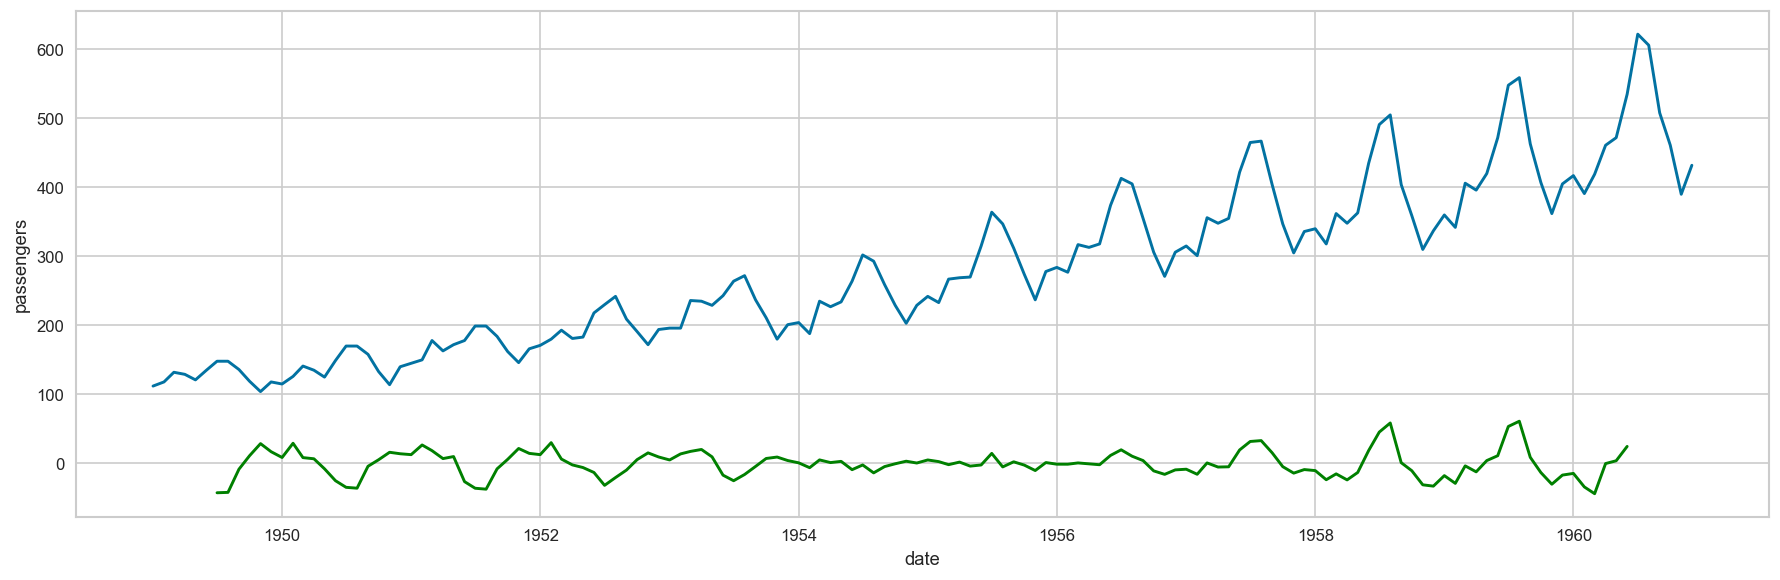

In [489]:
residual = decomposition.resid
fig, axis = plt.subplots(figsize=(15,5))
sns.lineplot(data=ts)
sns.lineplot(data=residual,color='green')
plt.tight_layout()
plt.show()

* La medición del ruido empieza pasado de enero de 1949 y termina antes de diciembre de 1961.

* Confirmamos que en parte de lo observado, que la carga de los residuos es más notable al inicio y final del periodo analizado.


#### **Autocorrelación**

* Correlación de una serie de tiempo con una copia retrasada de sí misma.

* Nos ayuda a ver si los valores en la serie de tiempo están correlacionados con los valores anteriores.

* Cómo de predecible es el futuro en base a lo que tienes en el presente.
    * A fecha de 1 de Enero 2026 como podemos predecir Feb,Mar,Abr 2027.

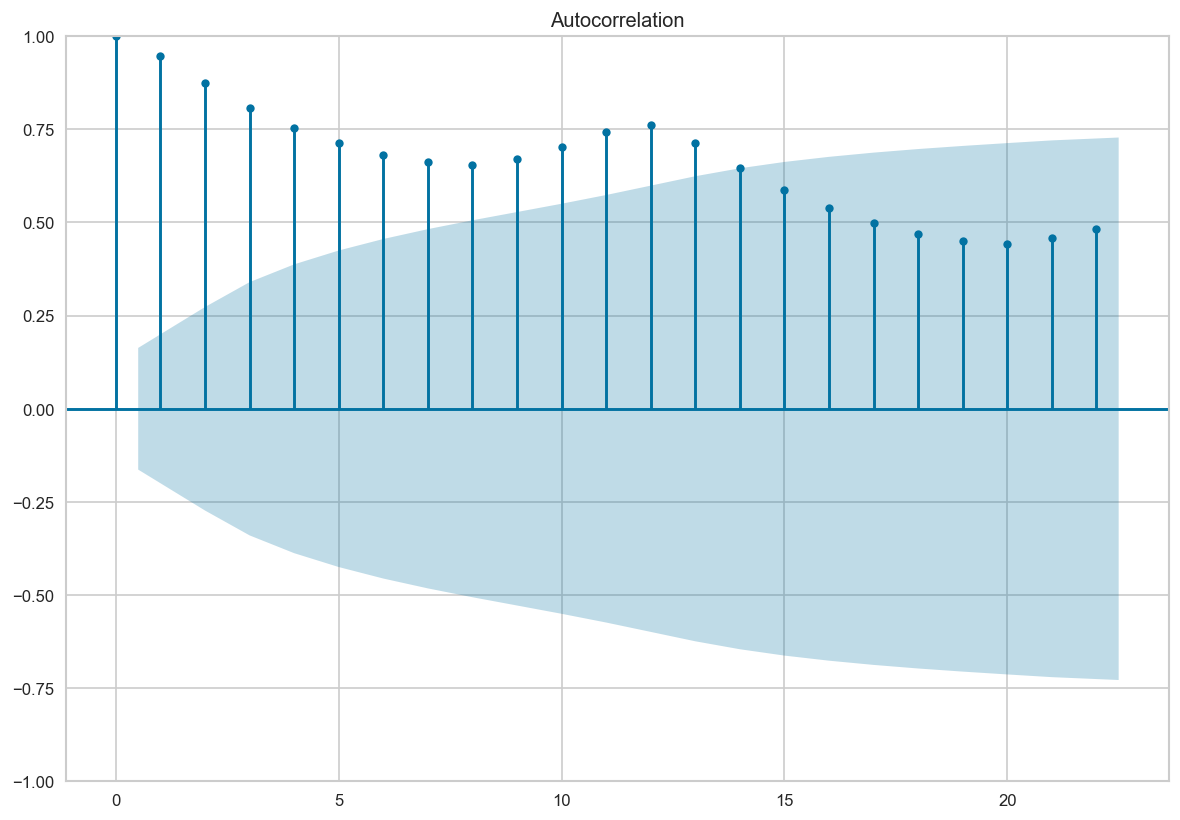

In [490]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(ts)
plt.tight_layout()
plt.show()

* El eje X va a representar las **ventanas (meses)** va de 0 meses hasta 24 meses (dos años).

* Y el eje Y va a representar que tan capaz es de predecir la serie con cierto éxito.

* Alta correlación entre los puntos y sus copias retradas, que disminuye a lo largo del tiempo.

### **Entrenamiento Modelo**

La previsión de series temporales puede clasificarse en las siguientes categorías:

* Modelos Clásicos & Estadísticos:
    * Medias Móviles.
    * Suavizado Exponencial.
    * ARIMA.
    * SARIMA.
    * TBATS.
* Aprendizaje Automático:
    * Regresión Lineal.
    * XGBoost.
    * Random Forest.
    * Cualquier modelo ML con métodos de reducción.
* Aprendizaje Profundo:
    * RNN.
    * LSTM.
    

#### **MODELOS ESTADÍSTICOS**

##### **ARIMA**

* Método clásico y popular.
* **ARIMA == SIGLAS == MEDIA MÓVIL INTEGRADA AUTORREGRESIVA**
* Pronostica series temporales basándose en sus propios valores pasados, es decir, sus propios retardos y los errores del pronóstico retardados.
* No admite datos estacionales

**Componentes**

* **Autoregresión (AR)** muestra una variable cambiante que hace regresión sobre sus propios valores retardados o anteriores.

* **Integrado (I)** representa la diferenciación de las observaciones brutas para permiten que la serie se vuelva estacionaria.

* **Media móvil (MA)** incorpora la dependencia entre una observacion y un error residuall de un modelo de media móvil aplicado a observaciones retardadas.

Vamos a transformar la serie para que sea esatacionaria, para ello vamos a aplicar **logaritmo** para reducir el efecto de los valores grandes.

* Existen otras técnicas de transformación:
    * Diferenciando los datos.
    * Tomando la raíz cuadrada de los datos
    * Tomando la raíz cúbica.
    * Cambio proporcional.

* Cuando la serie crece con el tiempo, las subidas se vuelven cada vez más grandes, lo que hace que la varianza no sea constante.

* El log “comprime” esos valores y hace que la serie sea más estable.

In [491]:
import numpy as np
ts_log = np.log(ts)
ts_log

date
1949-01-01    4.718499
1949-02-01    4.770685
1949-03-01    4.882802
1949-04-01    4.859812
1949-05-01    4.795791
                ...   
1960-08-01    6.406880
1960-09-01    6.230481
1960-10-01    6.133398
1960-11-01    5.966147
1960-12-01    6.068426
Name: passengers, Length: 144, dtype: float64

* Restamos cada valor con respecto al anterior para eliminar la tendencia.

* Si la serie va subiendo continuamente, no es estacionaria.

* Al hacer la diferencia, dejamos de ver niveles y pasamos a ver cambios, lo que suele eliminar ese crecimiento constante.

In [492]:
ts_diff = ts_log.diff().dropna()

* Restamos cada dato con el del mismo periodo anterior (por ejemplo, el mismo mes del año pasado).

* Esto elimina patrones repetitivos, como subidas o bajadas que ocurren cada año, haciendo que la serie deje de tener estacionalidad.

In [493]:
ts_stationary = ts_diff.diff(12).dropna()

* Verificamos que la serie sea estacionaria con la prueba de dicky-fuller.

In [494]:
test_stationarity(ts_stationary)

Resultados de la Prueba Dickey-Fuller


Test Statistic                  -4.443325
p-value                          0.000249
#Lags Used                      12.000000
Number of Observations Used    118.000000
Critical Value (1%)             -3.487022
Critical Value (5%)             -2.886363
Critical Value (10%)            -2.580009
dtype: float64

En el siguiente código vamos a pasar varios argumentos que son importantes:
* **ts** es la serie transformada, que sea estacionaria.
* **seasonal = True** es que la serie es estacionaria.
* **trace = True** muestre mensajes en consola.
* **m = 12** corresponde al mismo valor que utilizamos en la descomposición **period = 12** representa la ventana, usamos 12 porque el periodo es un año (12 meses tiene un año). Si tuviesemos horas del día el periodo sería 24.


In [495]:
from pmdarima import auto_arima
model = auto_arima(ts_stationary, seasonal=True, trace=True, m=12)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=-475.745, Time=0.56 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=-432.835, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=-472.814, Time=0.24 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=-481.421, Time=0.20 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=-434.830, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=-447.991, Time=0.07 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=-479.934, Time=0.32 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=-479.985, Time=0.62 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=-475.400, Time=0.22 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=-477.926, Time=0.49 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=-465.570, Time=0.09 sec
 ARIMA(1,0,1)(0,0,1)[12] intercept   : AIC=-479.936, Time=0.31 sec
 ARIMA(0,0,2)(0,0,1)[12] intercept   : AIC=-479.643, Time=0.35 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=-479.505, Time=0.18 sec
 ARIMA(1,0,2)(0,0,1

La función hace una busqueda en el espacio de soluciones posibles para estimar los mejores parámetros en este caso tendríamos un **ARIMA (0,0,1).**

Revisamos que devuelve el modelo con la función **.summary()** con información estadística de su rendimiento:

In [496]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  131
Model:             SARIMAX(0, 0, 1)x(0, 0, 1, 12)   Log Likelihood                 244.696
Date:                            Mon, 13 Apr 2026   AIC                           -483.393
Time:                                    18:54:02   BIC                           -474.767
Sample:                                02-01-1950   HQIC                          -479.888
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4018      0.073     -5.504      0.000      -0.545      -0.259
ma.S.L12      -0.5569      0.096     -5.784      0.000      -0.746      -0.368
sigma2         0.0013      0.000      9.121      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 1.90
Prob(Q):                              0.84   Prob(JB):                         0.39
Heteroskedasticity (H):               0.58   Skew:                             0.02
Prob(H) (two-sided):                  0.08   Kurtosis:                         3.59
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Hacemos la predicción del modelo, es decir, predecir el futuro para los próximos 10 meses.

In [497]:
forecast = model.predict(n_periods=10)
forecast

1961-01-01    0.012561
1961-02-01    0.007968
1961-03-01    0.048776
1961-04-01   -0.067942
1961-05-01    0.009675
1961-06-01    0.010935
1961-07-01   -0.012158
1961-08-01    0.021673
1961-09-01   -0.001810
1961-10-01   -0.018607
Freq: MS, dtype: float64

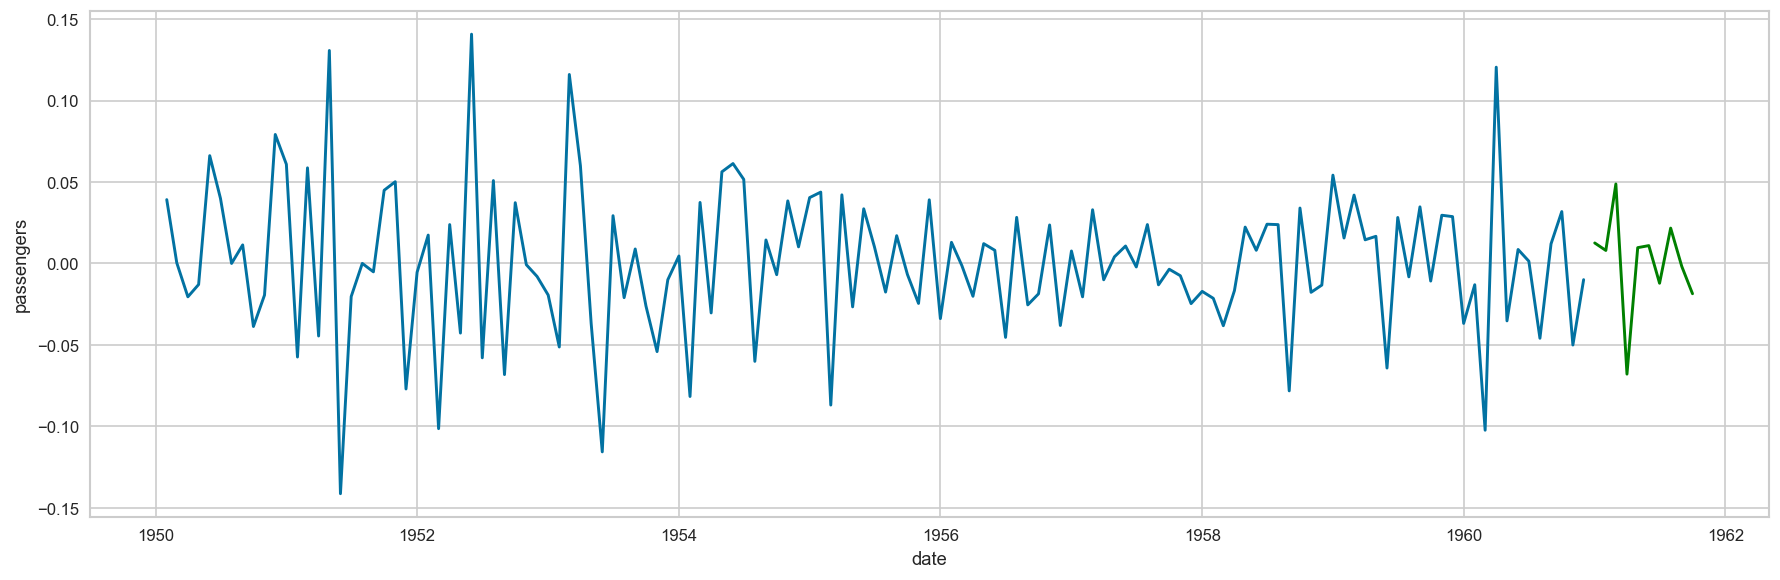

In [498]:
fig,axis = plt.subplots(figsize=(15,5))
sns.lineplot(data=ts_stationary)
sns.lineplot(data=forecast,color='green')
plt.tight_layout()
plt.show()

##### **SARIMA**

* Modelo autorregresivo integrado de media móvil estacional.
* Sus componentes son:
    * **S (Estacional)** se refiere a un modelo con componente estacional.
    * **AR (Autorregresión)** se refiere a que una variable cambiante regresa sobre sus propios valores rezagados o anteriores.
    * **I (Integrado)** representa la diferenciación de las observaciones brutas para permitir que la serie se vuelva estacionaroa.
    * **MA (Media Móvil)** incorpora la dependecia entre una observación y un error residual de un modelo de media móvil aplicado a observaciones rezagadas.

Para utilizar **SARIMA** necesitamos seleccionar los valores de p, d y q para ARIMA y los valores P, D y Q para el componente estacional. El propio modelo generará los valores óptimos de p,d y q que sean adecuados al conjunto de datos y permitan realizar mejores pronósticos.

In [499]:
import pmdarima as pmd

model=pmd.auto_arima(ts,start_p= 1 ,start_q= 1 ,test= 'adf' ,m= 12 ,seasonal= True ,trace= True )

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=1022.299, Time=0.32 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.07 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.09 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.393, Time=0.02 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1019.239, Time=0.19 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=1.18 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1020.493, Time=0.20 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.14 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=1021.120, Time=0.27 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1021.032, Time=0.33 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1019.178, Time=0.21 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1020.425, Time=0.07 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=inf, Time=1.03 sec
 ARIMA(0,1,1)(1,1,1)[12]     

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima=SARIMAX(ts,order=( 0 , 1 , 1 ),seasonal_order=( 2 , 1 , 0 , 12 ))
predicted=sarima.fit().predict();
predicted

1949-01-01      0.000000
1949-02-01    111.997178
1949-03-01    117.999698
1949-04-01    131.999295
1949-05-01    129.000151
                 ...    
1960-08-01    630.591419
1960-09-01    511.058149
1960-10-01    456.766670
1960-11-01    412.628553
1960-12-01    438.478199
Freq: MS, Name: predicted_mean, Length: 144, dtype: float64

Aquí obtuvimos los valores previstos para toda la serie...

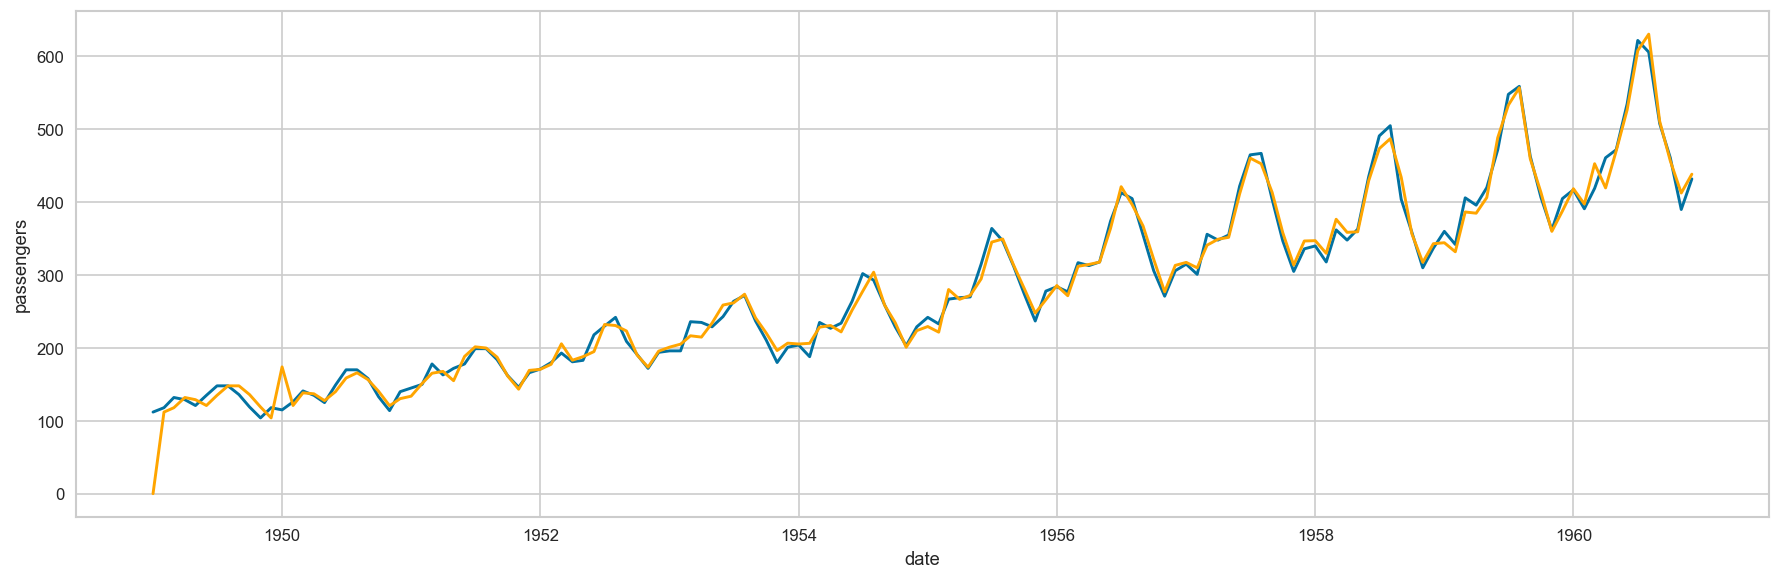

In [501]:
fig,axis = plt.subplots(figsize=(15,5))
sns.lineplot(data=ts)
sns.lineplot(data=predicted,color='orange')
plt.tight_layout()
plt.show()

Nosotros tenemos información de la serie real (ts) y de la predicción con el modelo SARIMA (predicted). Podemos calcular el residuo, que es equivalente a la diferencia entre lo real menos lo predicho.

In [502]:
resid = ts - predicted
resid

date
1949-01-01    112.000000
1949-02-01      6.002822
1949-03-01     14.000302
1949-04-01     -2.999295
1949-05-01     -8.000151
                 ...    
1960-08-01    -24.591419
1960-09-01     -3.058149
1960-10-01      4.233330
1960-11-01    -22.628553
1960-12-01     -6.478199
Length: 144, dtype: float64

Podríamos interpretar los resultados como:
* Positivos, el modelo se quedo corto.
* Negativos, el modelo se pasó.

Pero nosotros podemos calcular el error promedio (MAE).

In [503]:
#abs valor absoluto, quitamos signos.
mae = abs(resid).mean()
mae

10.038572271896644

El resultado nos dice que el modelo se equivoca 10 unidades en promedio.


Podríamos graficar los residuos para ver su distribución, lo ideal es que estén centrados en cero y con una forma de distribución normal, no tendríamos sesgo.

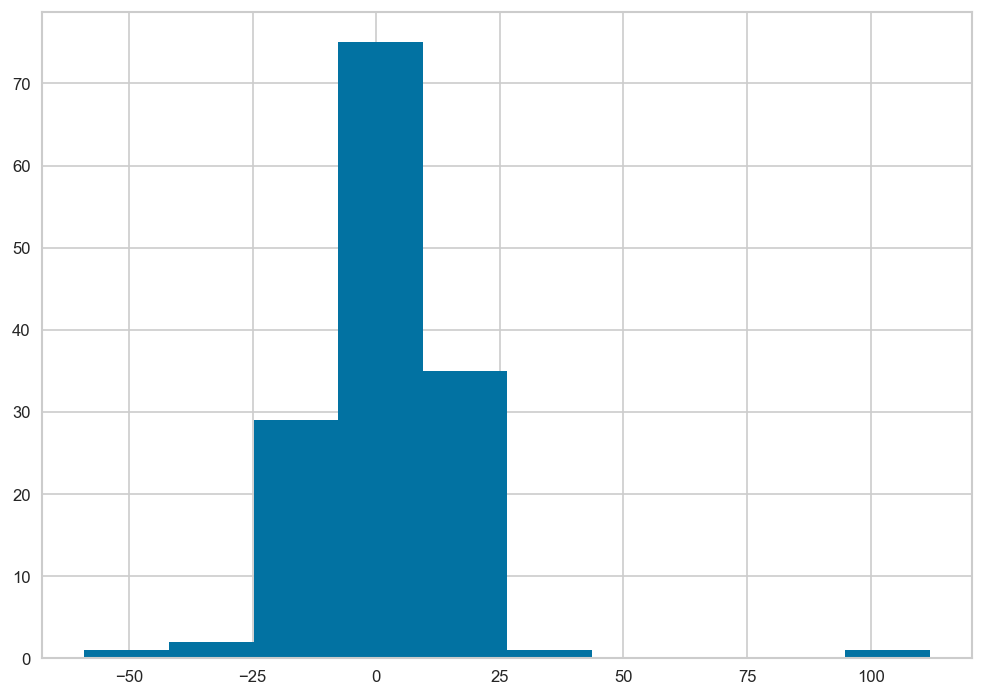

In [504]:
plt.hist(resid)
plt.show()

También podemos obtener la métrica MSE, el promedio de errores al cuadrado.

In [505]:
(resid**2).mean() #mse

240.95729381961735

In [506]:
rmse = np.sqrt((resid**2).mean()) #rmse
rmse

15.522799161865663

Aquí estamos obteniendo que el modelo se equivoca 15 unidades en promedio penalizando los errores grandes.

##### **SUAVIZADO EXPONENCIAL**

* Es una forma de predecir el futuro usando el pasado, pero: **da más importancia a los datos recientes que a los antiguos.**
* Pueden ampliarse para admitir datos con un componente tendencial o estacional.
* Asigna ponderaciones exponencialmente decrecientes para las observaciones más nuevas a las más antiguas.
    * Cuanto más antiguo son los datos, menos peso se les da.
    * Cuando son más recientes les da más peso.
* Existen varios tipos de suavizado:
    * **Simple:** sirve sólo si los datos son planos (no hay tendencia ni estacionalidad).
    * **Holt:** sirve cuando hay tendencia (sube o baja).
    * **Holt Winters:** sirve cuando hay tendencia y estacionalidad.

In [507]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model = ExponentialSmoothing(
    ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

pred = model.forecast(10)

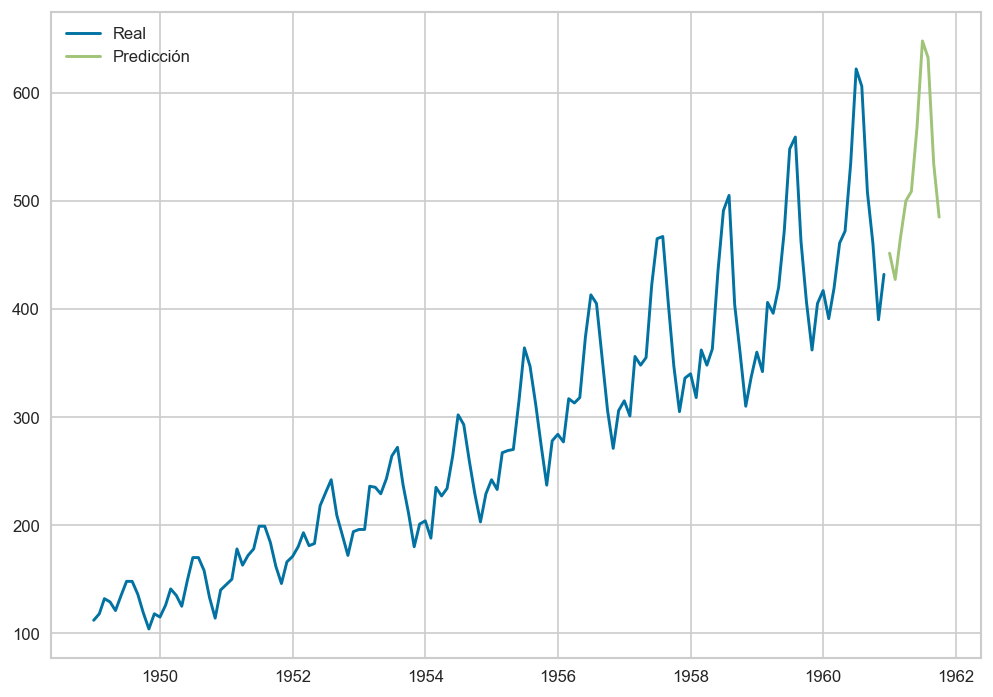

In [508]:
import matplotlib.pyplot as plt

plt.plot(ts, label="Real")
plt.plot(pred, label="Predicción")
plt.legend()
plt.show()

#### **APRENDIZAJE AUTOMÁTICO**

Con este método, extraemos las características con fecha para añadirlas en nuestra variable **X** y el valor de la serie temporal en nuestra variable **Y**

In [509]:
ts

date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: passengers, Length: 144, dtype: int64

En **series temporales** la división de entrenamiento y prueba deben respetar el **orden del tiempo** ya que no se pueden mezclar aleatoriamente.

* El conjunto de prueba representa los datos futuros rescpecto al entrenamiento.
* Conjunto de entenamiento contiene los datos anteriores a 1960.
* Conjunto de prueba contiene datos posteriores a 1960.

In [510]:
train = ts.loc[ts.index < "1960-01-01"]
test = ts.loc[ts.index >= "1960-01-01"]

In [511]:
train.head()

date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: passengers, dtype: int64

In [512]:
test.head()

date
1960-01-01    417
1960-02-01    391
1960-03-01    419
1960-04-01    461
1960-05-01    472
Name: passengers, dtype: int64

Utilizaremos PyCaret una de las bibliotecas de aprendizaje automático de código abierto y bajo código en Python que automatiza flujos de trabajo de aprendizaje automático.

In [513]:
train2 = train.to_frame(name="Passengers")
test2 = test.to_frame(name="Passengers")

In [ ]:
from pycaret.time_series import *

s = setup(data=train2, fh=len(test2), session_id=123)

# from pycaret.regression import *
# s = setup(
#     data=train2,
#     test_data=test2,
#     target='Passengers',
#     fold_strategy='timeseries',
#     fold=3,
#     transform_target=True,
#     session_id=123,
#     data_split_shuffle=False,  
#     fold_shuffle=False       
# )

,Description,Value
0,session_id,123
1,Target,Passengers
2,Approach,Univariate
3,Exogenous Variables,Not Present
4,Original data shape,"(132, 1)"
5,Transformed data shape,"(132, 1)"
6,Transformed train set shape,"(120, 1)"
7,Transformed test set shape,"(12, 1)"
8,Rows with missing values,0.0%
9,Fold Generator,ExpandingWindowSplitter


In [532]:
best = compare_models(sort = 'MAE')

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
exp_smooth,Exponential Smoothing,0.4607,0.5129,13.3715,16.6406,0.0356,0.0358,0.9062,0.0433
ets,ETS,0.4742,0.5237,13.7844,17.0058,0.0369,0.0370,0.9027,0.0767
arima,ARIMA,0.5027,0.5345,14.5649,17.3018,0.0395,0.0395,0.8979,0.0467
stlf,STLF,0.5089,0.5423,14.9430,17.7092,0.0405,0.0400,0.8925,0.0267
auto_arima,Auto ARIMA,0.5685,0.6045,16.3432,19.4468,0.0445,0.0447,0.8623,1.5367
theta,Theta Forecaster,0.6493,0.7206,18.6821,23.2613,0.0490,0.0503,0.8079,0.0200
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,0.8461,0.9340,24.0473,29.7831,0.0650,0.0669,0.6401,0.1100
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,0.8462,0.9340,24.0476,29.7834,0.0650,0.0669,0.6401,0.1567
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,0.8471,0.9352,24.0778,29.8242,0.0650,0.0670,0.6398,0.1067
lasso_cds_dt,Lasso w/ Cond. Deseasonalize & Detrending,0.8473,0.9356,24.0841,29.8403,0.0650,0.0669,0.6399,0.1100


In [519]:
results = pull()
results

,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
exp_smooth,Exponential Smoothing,0.4607,0.5129,13.3715,16.6406,0.0356,0.0358,0.9062,0.0433
ets,ETS,0.4742,0.5237,13.7844,17.0058,0.0369,0.037,0.9027,0.0600
arima,ARIMA,0.5027,0.5345,14.5649,17.3018,0.0395,0.0395,0.8979,0.0367
stlf,STLF,0.5089,0.5423,14.943,17.7092,0.0405,0.04,0.8925,0.0200
auto_arima,Auto ARIMA,0.5685,0.6045,16.3432,19.4468,0.0445,0.0447,0.8623,1.3267
theta,Theta Forecaster,0.6493,0.7206,18.6821,23.2613,0.049,0.0503,0.8079,0.0167
lr_cds_dt,Linear w/ Cond. Deseasonalize & Detrending,0.8461,0.934,24.0473,29.7831,0.065,0.0669,0.6401,0.0967
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,0.8462,0.934,24.0476,29.7834,0.065,0.0669,0.6401,0.0967
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,0.8471,0.9352,24.0778,29.8242,0.065,0.067,0.6398,0.1033
lasso_cds_dt,Lasso w/ Cond. Deseasonalize & Detrending,0.8473,0.9356,24.0841,29.8403,0.065,0.0669,0.6399,0.1033


Deberiamos obtener algo como esto para seleccionar el mejor modelo usando validación cruzada donde el mejor resultado se obtenga en función de la métrica MAE.

image18_rsgvrg.png

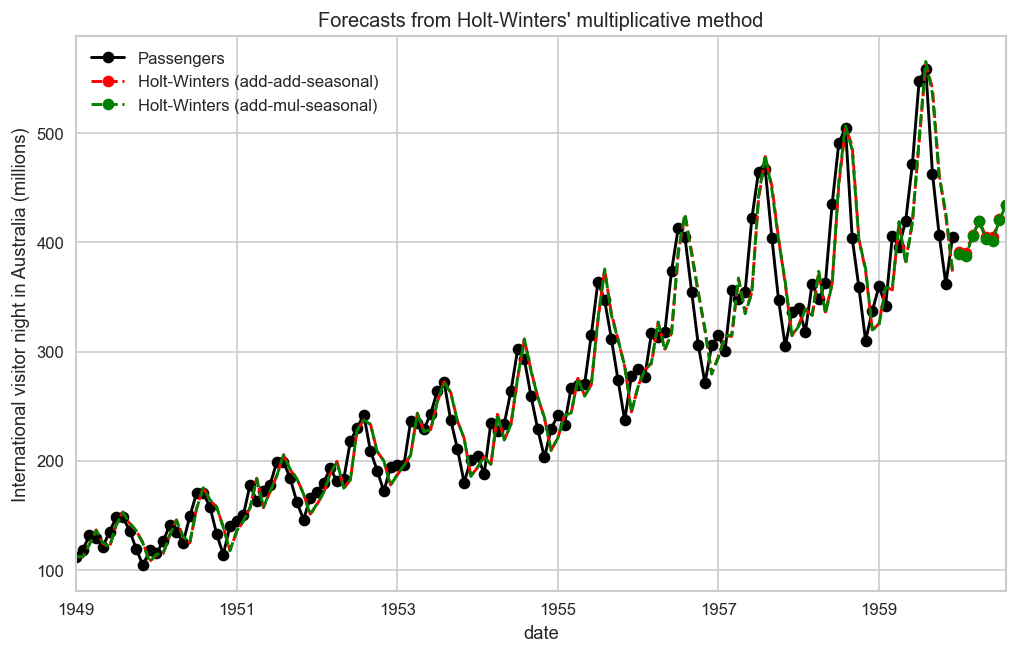

Figure 7.6: Forecasting international visitor nights in Australia using Holt-Winters method with both additive and multiplicative seasonality.


,Additive,Multiplicative,Additive Dam,Multiplica Dam
$\alpha$,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
$\beta$,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
$\phi$,NaN,NaN,9.925750e-01,9.924866e-01
$\gamma$,1.189955e-08,1.488005e-08,1.184633e-08,1.486177e-08
$l_0$,6.572459e+00,6.820832e+00,6.563555e+00,6.820886e+00
$b_0$,1.889973e-02,1.979546e-02,3.016312e-02,3.181544e-02
SSE,1.126657e+05,1.107770e+05,1.123527e+05,1.104607e+05


In [ ]:
from statsmodels.tsa.api import ExponentialSmoothing, Holt, SimpleExpSmoothing
fit1 = ExponentialSmoothing(
    train2,
    seasonal_periods=4,
    trend="add",
    seasonal="add",
    use_boxcox=True,
    initialization_method="estimated",
).fit()
fit2 = ExponentialSmoothing(
    train2,
    seasonal_periods=4,
    trend="add",
    seasonal="mul",
    use_boxcox=True,
    initialization_method="estimated",
).fit()
fit3 = ExponentialSmoothing(
    train2,
    seasonal_periods=4,
    trend="add",
    seasonal="add",
    damped_trend=True,
    use_boxcox=True,
    initialization_method="estimated",
).fit()
fit4 = ExponentialSmoothing(
    train2,
    seasonal_periods=4,
    trend="add",
    seasonal="mul",
    damped_trend=True,
    use_boxcox=True,
    initialization_method="estimated",
).fit()
results = pd.DataFrame(
    index=[r"$\alpha$", r"$\beta$", r"$\phi$", r"$\gamma$", r"$l_0$", "$b_0$", "SSE"]
)
params = [
    "smoothing_level",
    "smoothing_trend",
    "damping_trend",
    "smoothing_seasonal",
    "initial_level",
    "initial_trend",
]
results["Additive"] = [fit1.params[p] for p in params] + [fit1.sse]
results["Multiplicative"] = [fit2.params[p] for p in params] + [fit2.sse]
results["Additive Dam"] = [fit3.params[p] for p in params] + [fit3.sse]
results["Multiplica Dam"] = [fit4.params[p] for p in params] + [fit4.sse]

ax = train2.plot(
    figsize=(10, 6),
    marker="o",
    color="black",
    title="Forecasts from Holt-Winters' multiplicative method",
)
ax.set_ylabel("International visitor night in Australia (millions)")
ax.set_xlabel("Year")
fit1.fittedvalues.plot(ax=ax, style="--", color="red")
fit2.fittedvalues.plot(ax=ax, style="--", color="green")
fit1.forecast(8).rename("Holt-Winters (add-add-seasonal)").plot(ax = ax, style = "--", marker = "o", color = "red", legend=True)
fit2.forecast(8).rename("Holt-Winters (add-mul-seasonal)").plot(ax = ax, style = "--", marker = "o", color = "green", legend = True)

plt.show()
print("Figure 7.6: Forecasting international visitor nights in Australia using Holt-Winters method with both additive and multiplicative seasonality.")
results